In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data loading

In [8]:
employees_df = pd.read_csv(
    r"D:\mlprojects\trns_proj\data\employees_after_churn.csv"
)

employees_df.head()

,employee_id,gender,hub,pickup_hub,uses_company_transport,transport_shift,login_shift,transport_eligibility,extension_category,shift_logout,predicted_extension_minutes,safety_priority_score,requires_security_escort,home_distance_km,home_lat,home_lon
0,1,Female,Hopes,Hopes,False,NON_TRANSPORT,NON_TRANSPORT,FULL_HOME_DROP,NO_EXTENSION,2025-01-01 18:30:00,0,4.0,False,7.38,11.007393,77.022740
1,3,Female,Ganapathy,Ganapathy,False,NON_TRANSPORT,NON_TRANSPORT,FULL_HOME_DROP,NO_EXTENSION,2025-01-01 21:30:00,0,4.0,False,3.87,11.036700,76.984871
2,4,Female,Saravanampatti,Saravanampatti,True,04:30,19:30,FULL_HOME_DROP,NO_EXTENSION,2025-01-01 04:30:00,0,7.0,True,14.11,11.132525,77.008819
3,5,Male,Hopes,Hopes,False,NON_TRANSPORT,NON_TRANSPORT,FULL_HOME_DROP,NO_EXTENSION,2025-01-01 18:30:00,0,1.0,False,10.44,11.031401,77.050282
4,6,Male,Thudiyalur,Thudiyalur,False,NON_TRANSPORT,NON_TRANSPORT,FULL_HOME_DROP,NO_EXTENSION,2025-01-01 21:30:00,0,1.0,False,11.74,11.122190,76.962961


# Transport User Analysis

In [9]:
transport_df = (
    employees_df[
        (employees_df["uses_company_transport"] == True)
        &
        (employees_df["transport_shift"] != "NON_TRANSPORT")
    ]
)

transport_df.info()

<class 'pandas.DataFrame'>
Index: 896 entries, 2 to 1815
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  896 non-null    int64  
 1   gender                       896 non-null    str    
 2   hub                          896 non-null    str    
 3   pickup_hub                   896 non-null    str    
 4   uses_company_transport       896 non-null    bool   
 5   transport_shift              896 non-null    str    
 6   login_shift                  896 non-null    str    
 7   transport_eligibility        896 non-null    str    
 8   extension_category           896 non-null    str    
 9   shift_logout                 896 non-null    str    
 10  predicted_extension_minutes  896 non-null    int64  
 11  safety_priority_score        896 non-null    float64
 12  requires_security_escort     896 non-null    bool   
 13  home_distance_km             896 no

## Hub Distribution
Which hubs generate the most transport demand?

In [10]:
transport_df["hub"].value_counts()

hub
Saravanampatti    303
Singanallur       214
Thudiyalur        152
Hopes             139
Ganapathy          88
Name: count, dtype: int64

<Axes: xlabel='hub'>

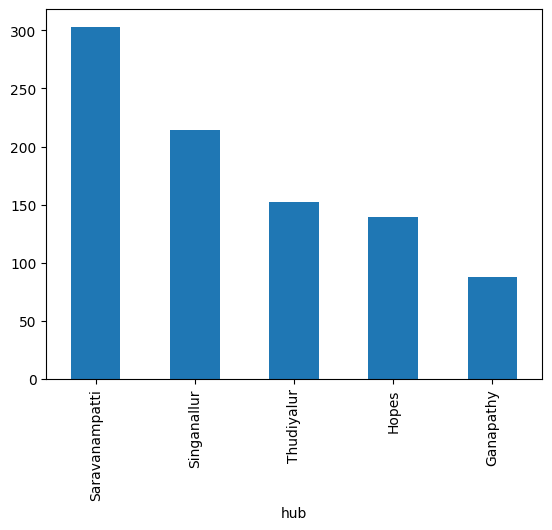

In [11]:
# bar chart
transport_df["hub"].value_counts().plot(kind="bar")

In [12]:
# Logout Shift Distribution
# 03:30 vs 04:30 demand?
transport_df["transport_shift"].value_counts()

transport_shift
04:30    527
03:30    369
Name: count, dtype: int64

# Hub + Shift Analysis
Should clustering be done
per hub + shift?


In [13]:
(
    transport_df
    .groupby(
        ["hub", "transport_shift"]
    )
    .size()
    .reset_index(
        name="employee_count"
    )
)

,hub,transport_shift,employee_count
0,Ganapathy,03:30,33
1,Ganapathy,04:30,55
2,Hopes,03:30,60
3,Hopes,04:30,79
4,Saravanampatti,03:30,126
5,Saravanampatti,04:30,177
6,Singanallur,03:30,73
7,Singanallur,04:30,141
8,Thudiyalur,03:30,77
9,Thudiyalur,04:30,75


In [25]:
group_summary = (
    transport_df
    .groupby(
        ["hub", "transport_shift"]
    )
    .size()
    .reset_index(
        name="employee_count"
    )
)

group_summary.sort_values(
    "employee_count",
    ascending=False,
)

,hub,transport_shift,employee_count
5,Saravanampatti,04:30,177
7,Singanallur,04:30,141
4,Saravanampatti,03:30,126
3,Hopes,04:30,79
8,Thudiyalur,03:30,77
9,Thudiyalur,04:30,75
6,Singanallur,03:30,73
2,Hopes,03:30,60
1,Ganapathy,04:30,55
0,Ganapathy,03:30,33


# Geographic Analysis

In [ ]:
# Coordinate Summary
transport_df[
    ["home_lat", "home_lon"]
].describe()
'''
Lat Range 10.75 → 11.31
Lon Range 76.67 → 77.27
This is a relatively small operating area
DBSCAN may actually work very well. after proper scaling

'''

,home_lat,home_lon
count,896.000000,896.000000
mean,11.048725,77.001758
std,0.053196,0.054563
min,10.749133,76.674470
25%,11.011665,76.972430
50%,11.054644,77.004290
75%,11.083839,77.036047
max,11.306860,77.266561


In [17]:
# Home Distance Analysis
# How far are employees living from hubs?
transport_df[
    "home_distance_km"
].describe()

count    896.000000
mean       9.425848
std        4.394326
min        0.390000
25%        6.805000
50%        9.060000
75%       11.372500
max       36.660000
Name: home_distance_km, dtype: float64

# Employee Location Map

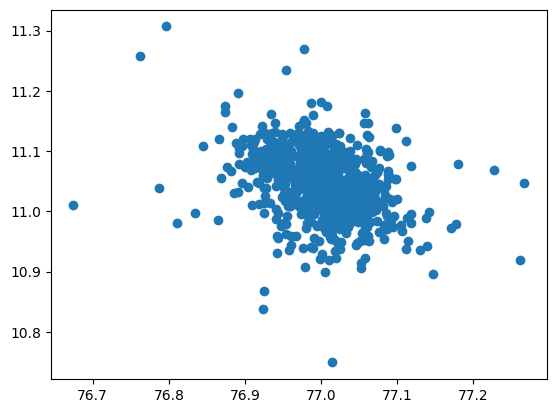

In [19]:
# Do natural clusters exist?
plt.scatter(
    transport_df["home_lon"],
    transport_df["home_lat"]
)

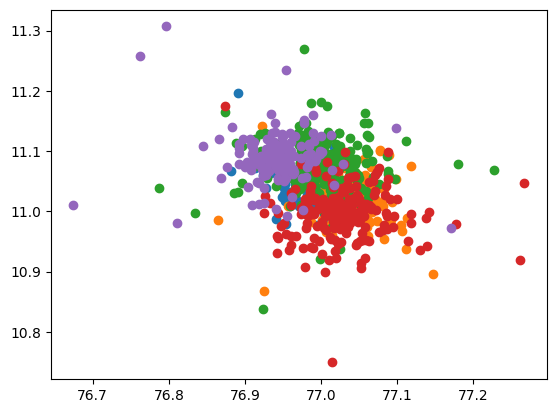

In [ ]:
# Hub coloured map
# Are hubs already geographic clusters?
for hub, subset in transport_df.groupby("hub"):

    plt.scatter(
        subset["home_lon"],
        subset["home_lat"],
        label=hub,
    )

'''
Hubs Are NOT Geographically Separated
are heavily overlapping
'''    

In [ ]:
# Hub + Shift Maps
# Do employees within a hub form multiple geographic clusters?
subset = transport_df[
    (transport_df["hub"] == "HOPES")
    &
    (transport_df["transport_shift"] == "04:30")
]


Before EDA we assumed Hub + Shift clustering
eda says Employees from different hubs live in the same geography.
so hub-first clustering will create artificial clusters.

In [26]:
# Hub vs Distance Analysis
# Do some hubs serve mostly nearby employees 
# while others serve long-distance employees?
(
    transport_df
    .groupby("hub")["home_distance_km"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
    .sort_values(
        "mean",
        ascending=False,
    )
)

,count,mean,median,min,max
hub,,,,,
Hopes,139,10.686475,10.540,0.83,24.83
Saravanampatti,303,9.747063,9.310,1.04,30.09
Thudiyalur,152,9.633750,8.960,1.06,36.66
Singanallur,214,9.522430,8.985,0.77,35.04
Ganapathy,88,5.734659,5.465,0.39,21.15


In [27]:
# Shift vs Distance Analysis
# Are 04:30 employees living farther away?
(
    transport_df
    .groupby(
        "transport_shift"
    )["home_distance_km"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
        ]
    )
)

,count,mean,median,min,max
transport_shift,,,,,
03:30,369,9.217588,8.93,0.77,30.71
04:30,527,9.571670,9.19,0.39,36.66


In [28]:
# Escort Analysis
# How many escort-required employees exist?
(
    transport_df[
        "requires_security_escort"
    ]
    .value_counts()
)

requires_security_escort
False    528
True     368
Name: count, dtype: int64

In [29]:
(
    transport_df
    .groupby("hub")
    [
        "requires_security_escort"
    ]
    .sum()
    .sort_values(
        ascending=False
    )
)

hub
Saravanampatti    132
Singanallur        90
Thudiyalur         66
Hopes              45
Ganapathy          35
Name: requires_security_escort, dtype: int64

In [30]:
# Transport Shift by Hub
# Which hub creates most 03:30 demand?
# Which hub creates most 04:30 demand?
pd.crosstab(
    transport_df["hub"],
    transport_df[
        "transport_shift"
    ]
)

transport_shift,03:30,04:30
hub,,
Ganapathy,33,55
Hopes,60,79
Saravanampatti,126,177
Singanallur,73,141
Thudiyalur,77,75


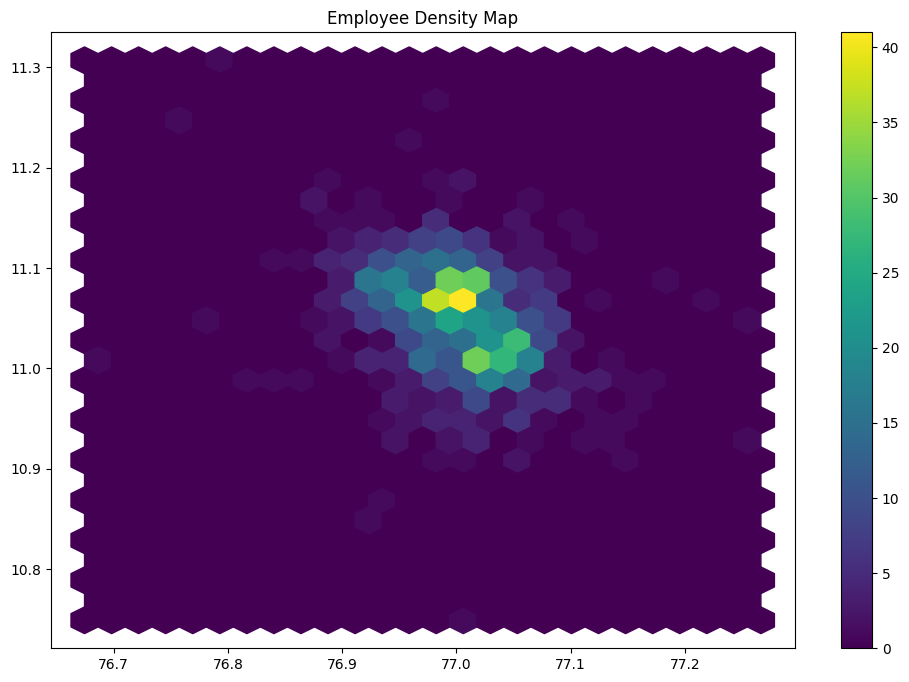

In [31]:
# Geographic Density
# Do we have hotspot regions?
plt.figure(
    figsize=(12,8)
)

plt.hexbin(
    transport_df["home_lon"],
    transport_df["home_lat"],
    gridsize=25,
)

plt.colorbar()

plt.title(
    "Employee Density Map"
)

plt.show()

In [32]:
# Outlier Detection
# Do we have employees living extremely far away?
transport_df[
    "home_distance_km"
].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
    ]
)

count    896.000000
mean       9.425848
std        4.394326
min        0.390000
90%       14.305000
95%       16.365000
99%       24.857000
max       36.660000
Name: home_distance_km, dtype: float64

In [33]:
transport_df[
    transport_df[
        "home_distance_km"
    ]
    >
    transport_df[
        "home_distance_km"
    ]
    .quantile(
        0.99
    )
]
[
    [
        "employee_id",
        "hub",
        "transport_shift",
        "home_distance_km",
    ]
]

[['employee_id', 'hub', 'transport_shift', 'home_distance_km']]

1. Number of transport users

2. Hub-wise demand distribution

3. Shift-wise demand distribution

4. Distance distribution

5. Escort population

6. Geographic hotspots

7. Outlier employees

8. Recommended clustering strategy

In [34]:
pd.crosstab(
    transport_df["hub"],
    transport_df["transport_shift"]
)

transport_shift,03:30,04:30
hub,,
Ganapathy,33,55
Hopes,60,79
Saravanampatti,126,177
Singanallur,73,141
Thudiyalur,77,75


In [35]:
transport_df.groupby(
    "hub"
)["home_distance_km"].mean()

hub
Ganapathy          5.734659
Hopes             10.686475
Saravanampatti     9.747063
Singanallur        9.522430
Thudiyalur         9.633750
Name: home_distance_km, dtype: float64

In [36]:
# Distance by Hub
(
    transport_df
    .groupby("hub")
    ["home_distance_km"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "max"
        ]
    )
)

,count,mean,median,max
hub,,,,
Ganapathy,88,5.734659,5.465,21.15
Hopes,139,10.686475,10.540,24.83
Saravanampatti,303,9.747063,9.310,30.09
Singanallur,214,9.522430,8.985,35.04
Thudiyalur,152,9.633750,8.960,36.66


In [37]:
transport_df.groupby(
    "hub"
)["home_distance_km"].agg(
    ["mean","median","max"]
)

,mean,median,max
hub,,,
Ganapathy,5.734659,5.465,21.15
Hopes,10.686475,10.540,24.83
Saravanampatti,9.747063,9.310,30.09
Singanallur,9.522430,8.985,35.04
Thudiyalur,9.633750,8.960,36.66


In [38]:
shift_0330 = (
    transport_df[
        transport_df[
            "transport_shift"
        ] == "03:30"
    ]
)

len(shift_0330)

369

In [39]:
shift_0430 = (
    transport_df[
        transport_df[
            "transport_shift"
        ] == "04:30"
    ]
)

len(shift_0430)

527

# Executive Summary of EDA
1. Employee Geography
    - density map shows: One major central hotspot + A few sparse outliers
    - not 5 clearly separated geographic regions
    - hub-colored scatter plot showed heavy overlap. Hub ≠ Geography. This means: Clustering by hub first is probably wrong.

2. Distance Analysis    
| Hub            | Avg Distance |
| -------------- | -----------: |
| Ganapathy      |      5.73 km |
| Hopes          |     10.69 km |
| Saravanampatti |      9.75 km |
| Singanallur    |      9.52 km |
| Thudiyalur     |      9.63 km |
    - ganapthy is low average distance

3. Shift Analysis
| Shift | Avg Distance |
| ----- | -----------: |
| 03:30 |      9.22 km |
| 04:30 |      9.57 km |
    - difference 0.35km therefore shift does NOT strongly influence geography.

4. Outliers
    - 99th percentile 24.86km
    - max 36.66km     
    - small number of employees living very far away.

Finding 1:
Hubs are geographically overlapping.

Finding 2:
Employees form one major geographic hotspot.

Finding 3:
Ganapathy has significantly shorter travel distances.

Finding 4:
03:30 and 04:30 populations are geographically similar.

So, Synthetic employee geography is not realistic enough.
Improve employee geography generation before finalizing clustering architecture.

In [40]:
# Hub+Shift EDA
for hub, shift_df in (
    transport_df
    .groupby(
        ["hub", "transport_shift"]
    )
):
    
    print(
        hub,
        len(shift_df)
    )

('Ganapathy', '03:30') 33
('Ganapathy', '04:30') 55
('Hopes', '03:30') 60
('Hopes', '04:30') 79
('Saravanampatti', '03:30') 126
('Saravanampatti', '04:30') 177
('Singanallur', '03:30') 73
('Singanallur', '04:30') 141
('Thudiyalur', '03:30') 77
('Thudiyalur', '04:30') 75


<Axes: xlabel='home_distance_km', ylabel='transport_shift'>

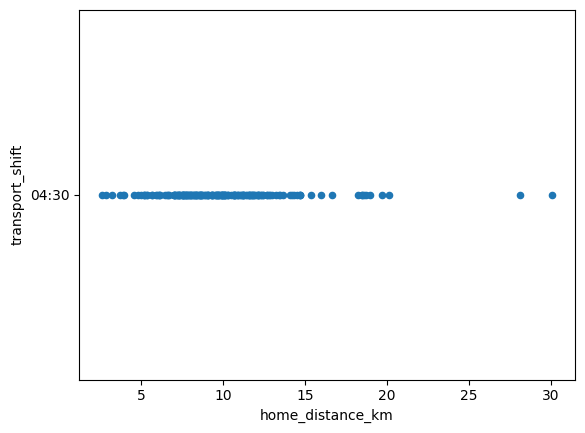

In [45]:
# location scatter plot for Saravanampatti + 04:30

subset = transport_df[
    (transport_df["hub"] == "Saravanampatti")
    &
    (transport_df["transport_shift"] == "04:30")
]

subset.plot.scatter(
    x="home_distance_km",
    y="transport_shift"
)
 

In [46]:
group_summary = (
    transport_df
    .groupby(
        [
            "hub",
            "transport_shift"
        ]
    )
    .agg(
        employee_count=(
            "employee_id",
            "count"
        ),
        avg_distance=(
            "home_distance_km",
            "mean"
        )
    )
    .reset_index()
)

group_summary

,hub,transport_shift,employee_count,avg_distance
0,Ganapathy,03:30,33,6.215758
1,Ganapathy,04:30,55,5.446000
2,Hopes,03:30,60,10.477667
3,Hopes,04:30,79,10.845063
4,Saravanampatti,03:30,126,9.366349
5,Saravanampatti,04:30,177,10.018079
6,Singanallur,03:30,73,9.377123
7,Singanallur,04:30,141,9.597660
8,Thudiyalur,03:30,77,9.127532
9,Thudiyalur,04:30,75,10.153467


In [47]:
for _, row in group_summary.iterrows():

    print(
        row["hub"],
        row["transport_shift"],
        row["employee_count"],
    )

Ganapathy 03:30 33
Ganapathy 04:30 55
Hopes 03:30 60
Hopes 04:30 79
Saravanampatti 03:30 126
Saravanampatti 04:30 177
Singanallur 03:30 73
Singanallur 04:30 141
Thudiyalur 03:30 77
Thudiyalur 04:30 75


In [48]:
# Operational Cluster Sizing Analysis
group_summary[
    "suggested_clusters"
] = (
    group_summary[
        "employee_count"
    ] // 12
).clip(
    lower=2
)

group_summary

,hub,transport_shift,employee_count,avg_distance,suggested_clusters
0,Ganapathy,03:30,33,6.215758,2
1,Ganapathy,04:30,55,5.446000,4
2,Hopes,03:30,60,10.477667,5
3,Hopes,04:30,79,10.845063,6
4,Saravanampatti,03:30,126,9.366349,10
5,Saravanampatti,04:30,177,10.018079,14
6,Singanallur,03:30,73,9.377123,6
7,Singanallur,04:30,141,9.597660,11
8,Thudiyalur,03:30,77,9.127532,6
9,Thudiyalur,04:30,75,10.153467,6


- 10 operational transport groups
- most transport cost occurs: Saravanampatti 04:30, Singanallur 04:30, Saravanampatti 03:30 - 444 employees
- ganapathy avg distance is low(5.5 km)- cost per employee low
- ML strategy
    - X-->standardize-->models-->best models-->assign cluster

EDA
↓
Business Rules
↓
Prototype
↓
Production Code

In [49]:
def get_cluster_search_range(
    employee_count: int,
) -> tuple[int, int]:

    suggested_k = max(
        2,
        employee_count // 12,
    )

    min_k = max(
        2,
        suggested_k - 2,
    )

    max_k = suggested_k + 2

    return (
        min_k,
        max_k,
    )

In [50]:
for count in [
    33,
    55,
    60,
    79,
    126,
    177,
]:
    
    print(
        count,
        get_cluster_search_range(
            count
        )
    )

33 (2, 4)
55 (2, 6)
60 (3, 7)
79 (4, 8)
126 (8, 12)
177 (12, 16)


# Clustering Prototype 1

In [51]:
# Saravanampatti 04:30 177 employees
largest_group = transport_df[
    (transport_df["hub"] == "Saravanampatti")
    &
    (transport_df["transport_shift"] == "04:30")
].copy()

print(len(largest_group))

177


In [52]:
# Create coordinate matrix.
X = largest_group[
    [
        "home_lat",
        "home_lon",
    ]
].values

In [53]:
# Scale coordinates.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

In [54]:
# Determine search range.

min_k, max_k = get_cluster_search_range(
    len(largest_group)
)

print(
    min_k,
    max_k,
)

12 16


In [55]:
# run kmeans only
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(
    min_k,
    max_k + 1,
):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels,
    )

    results.append(
        {
            "k": k,
            "silhouette": score,
        }
    )

In [56]:
results_df = pd.DataFrame(
    results
)

results_df.sort_values(
    "silhouette",
    ascending=False,
)

,k,silhouette
4,16,0.356008
3,15,0.355193
1,13,0.345865
0,12,0.344397
2,14,0.341062


- Business-driven clustering did NOT collapse. Silhouette ≈ 0.35 is still reasonably stable.
- not optimize for: Highest silhouette score alone. We should optimize for: Operationally useful cluster sizes + Acceptable silhouette score

In [57]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


def benchmark_group_kmeans(
    group_df: pd.DataFrame,
):

    X = group_df[
        [
            "home_lat",
            "home_lon",
        ]
    ].values

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X
    )

    min_k, max_k = (
        get_cluster_search_range(
            len(group_df)
        )
    )

    best_score = -1

    best_k = None

    best_labels = None

    results = []

    for k in range(
        min_k,
        max_k + 1,
    ):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10,
        )

        labels = model.fit_predict(
            X_scaled
        )

        score = silhouette_score(
            X_scaled,
            labels,
        )

        results.append(
            {
                "k": k,
                "silhouette": score,
            }
        )

        if score > best_score:

            best_score = score

            best_k = k

            best_labels = labels

    return {

        "best_k": best_k,

        "best_score": best_score,

        "labels": best_labels,

        "results_df": pd.DataFrame(
            results
        ),
    }

In [58]:
summary_results = []

for (
    hub,
    transport_shift,
), group_df in transport_df.groupby(
    [
        "hub",
        "transport_shift",
    ]
):

    result = (
        benchmark_group_kmeans(
            group_df
        )
    )

    summary_results.append(
        {
            "hub": hub,

            "transport_shift":
            transport_shift,

            "employee_count":
            len(group_df),

            "best_k":
            result[
                "best_k"
            ],

            "best_silhouette":
            round(
                result[
                    "best_score"
                ],
                4,
            ),

            "avg_cluster_size":
            round(
                len(group_df)
                /
                result["best_k"],
                2,
            ),
        }
    )

In [ ]:
# How many operational geographic zones exist inside each transport group? 
cluster_summary = pd.DataFrame(
    summary_results
)

cluster_summary.sort_values(
    [
        "employee_count"
    ],
    ascending=False,
)

,hub,transport_shift,employee_count,best_k,best_silhouette,avg_cluster_size
5,Saravanampatti,04:30,177,16,0.3560,11.06
7,Singanallur,04:30,141,10,0.3745,14.10
4,Saravanampatti,03:30,126,12,0.3546,10.50
3,Hopes,04:30,79,6,0.3686,13.17
8,Thudiyalur,03:30,77,8,0.3790,9.62
9,Thudiyalur,04:30,75,4,0.4351,18.75
6,Singanallur,03:30,73,7,0.4199,10.43
2,Hopes,03:30,60,4,0.3505,15.00
1,Ganapathy,04:30,55,6,0.4066,9.17
0,Ganapathy,03:30,33,2,0.6555,16.50


- Most groups naturally converge to: 9–15 employees per cluster
- Business Rule (employee_count // 12) + KMeans Optimization is Working Strategy
- 177 employees--> 16 clusters--> 11 employees per cluster
- Directly usable for: Cab Allocation, Route Optimization

Clustering Decision:
    - group_level = ["hub", "transport_shift"]
    - X --> standardisation--> cluster search emp count//12 ± 2


In [60]:
# cluster size distribution.
model = KMeans(
    n_clusters=16,
    random_state=42,
    n_init=10,
)

labels = model.fit_predict(
    X_scaled
)

largest_group[
    "cluster_id"
] = labels

In [61]:
largest_group[
    "cluster_id"
].value_counts()

cluster_id
0     36
8     36
10    25
9     22
1     18
14     9
6      7
4      6
3      5
11     3
7      3
13     2
2      2
5      1
15     1
12     1
Name: count, dtype: int64

- We expected: 177 / 16 ≈ 11 employees per cluster like(10,12,11,9,13,...)
- but we got 36, 36, 25,....
- KMeans is forcing spherical clusters and several centroids are capturing only: 1–3 employees while others capture: 25–36 employees
- 1,1,1.. dedicated cab--> cost explode

# multi-model benchmark prototype

In [62]:
# Create Cluster Quality Function
import numpy as np


def calculate_cluster_balance(
    labels,
):

    cluster_sizes = (
        pd.Series(labels)
        .value_counts()
        .values
    )

    return {

        "cluster_count":
        len(cluster_sizes),

        "largest_cluster":
        cluster_sizes.max(),

        "smallest_cluster":
        cluster_sizes.min(),

        "avg_cluster_size":
        cluster_sizes.mean(),

        "cluster_std":
        cluster_sizes.std(),
    }

In [63]:
# KMeans Benchmark
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def benchmark_kmeans(
    X_scaled,
    min_k,
    max_k,
):

    results = []

    for k in range(
        min_k,
        max_k + 1,
    ):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10,
        )

        labels = model.fit_predict(
            X_scaled
        )

        silhouette = (
            silhouette_score(
                X_scaled,
                labels,
            )
        )

        balance = (
            calculate_cluster_balance(
                labels
            )
        )

        results.append(
            {
                "model":
                "KMeans",

                "k":
                k,

                "silhouette":
                silhouette,

                **balance,
            }
        )

    return pd.DataFrame(
        results
    )

In [64]:
from sklearn.cluster import (
    MiniBatchKMeans
)


def benchmark_minibatch(
    X_scaled,
    min_k,
    max_k,
):

    results = []

    for k in range(
        min_k,
        max_k + 1,
    ):

        model = (
            MiniBatchKMeans(
                n_clusters=k,
                random_state=42,
                batch_size=64,
                n_init=10,
            )
        )

        labels = (
            model.fit_predict(
                X_scaled
            )
        )

        silhouette = (
            silhouette_score(
                X_scaled,
                labels,
            )
        )

        balance = (
            calculate_cluster_balance(
                labels
            )
        )

        results.append(
            {
                "model":
                "MiniBatchKMeans",

                "k":
                k,

                "silhouette":
                silhouette,

                **balance,
            }
        )

    return pd.DataFrame(
        results
    )

In [65]:
from sklearn.cluster import (
    AgglomerativeClustering
)


def benchmark_agglomerative(
    X_scaled,
    min_k,
    max_k,
):

    results = []

    for k in range(
        min_k,
        max_k + 1,
    ):

        model = (
            AgglomerativeClustering(
                n_clusters=k
            )
        )

        labels = (
            model.fit_predict(
                X_scaled
            )
        )

        silhouette = (
            silhouette_score(
                X_scaled,
                labels,
            )
        )

        balance = (
            calculate_cluster_balance(
                labels
            )
        )

        results.append(
            {
                "model":
                "Agglomerative",

                "k":
                k,

                "silhouette":
                silhouette,

                **balance,
            }
        )

    return pd.DataFrame(
        results
    )

In [66]:
min_k, max_k = (
    get_cluster_search_range(
        len(largest_group)
    )
)

kmeans_df = benchmark_kmeans(
    X_scaled,
    min_k,
    max_k,
)

mini_df = benchmark_minibatch(
    X_scaled,
    min_k,
    max_k,
)

agg_df = benchmark_agglomerative(
    X_scaled,
    min_k,
    max_k,
)

all_models = pd.concat(
    [
        kmeans_df,
        mini_df,
        agg_df,
    ],
    ignore_index=True,
)

In [67]:
all_models.sort_values(
    [
        "silhouette"
    ],
    ascending=False,
)

,model,k,silhouette,cluster_count,largest_cluster,smallest_cluster,avg_cluster_size,cluster_std
4,KMeans,16,0.356008,16,36,1,11.062500,11.955484
3,KMeans,15,0.355193,15,51,1,11.800000,13.658697
1,KMeans,13,0.345865,13,44,1,13.615385,13.947917
0,KMeans,12,0.344397,12,50,1,14.750000,14.776812
10,Agglomerative,12,0.342013,12,59,1,14.750000,18.708844
2,KMeans,14,0.341062,14,45,1,12.642857,12.658183
14,Agglomerative,16,0.339851,16,48,1,11.062500,12.735132
13,Agglomerative,15,0.338178,15,48,1,11.800000,12.833290
12,Agglomerative,14,0.336215,14,48,1,12.642857,12.898544
11,Agglomerative,13,0.321878,13,59,1,13.615385,15.721316


- issue is: The underlying employee geography does not naturally support 12-16 clusters.
- We forced: 177 employees-->12-16 clusters--> But geography says: I don't have 16 natural groups.
- So every algorithm creates: few large clusters + many tiny clusters
- Earlier we asked: Can clustering tell us how many routes we need? No
- Route count is a business decision. Cluster count is a geography decision. 
These are different.
- decision
    - forecast demand --> natural geo clustering (4 or 5 cluster )--> cab allocate (cluster A =45, 45/12=4 vehicles)

# find the natural geographic clusters.

In [68]:
results = []

for k in range(2, 21):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    labels = model.fit_predict(
        X_scaled
    )

    results.append(
        {
            "k": k,
            "silhouette":
            silhouette_score(
                X_scaled,
                labels,
            ),
        }
    )

pd.DataFrame(
    results
)

,k,silhouette
0,2,0.305484
1,3,0.355969
2,4,0.349686
3,5,0.361091
4,6,0.349745
5,7,0.293554
6,8,0.318482
7,9,0.321264
8,10,0.334832
9,11,0.332078


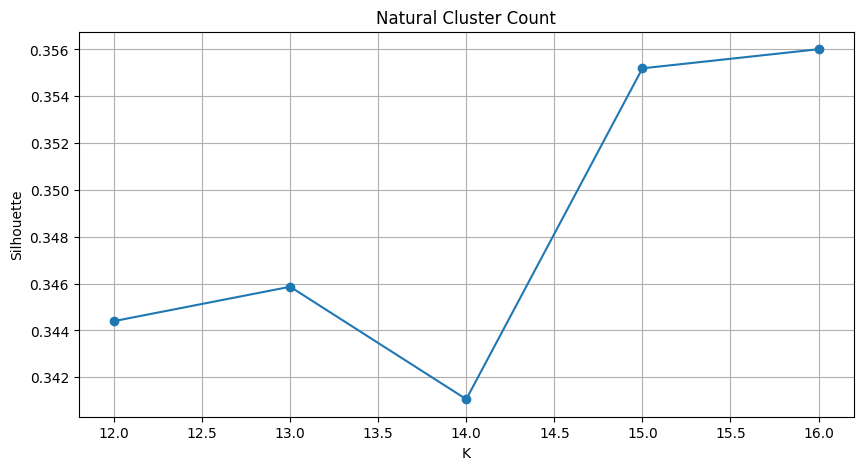

In [69]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    results_df["k"],
    results_df["silhouette"],
    marker="o",
)

plt.xlabel("K")
plt.ylabel("Silhouette")

plt.title(
    "Natural Cluster Count"
)

plt.grid(True)

plt.show()

- silhouettes are: diff between best and worst:0.356 - 0.341 = 0.015 very low
- This means: There is NO strong natural cluster count.
- If there were natural geographic zones, we'd see:(K=4 → 0.55,K=5 → 0.60, K=6 → 0.52)  with a clear peak. Instead: Everything is flat.
- Flat Mean? Usually one of these:
    - Case 1 Synthetic geography is too uniform. Which matches our earlier EDA findings.
    - Employees are one large cloud. Which also matches: Employee Density Map

- This means: Clustering is not the primary optimization lever. Instead: Vehicle allocation, Route sequencing will drive most of the business value.    